# LeNet-5 — PyTorch

Implementação da arquitetura clássica **LeNet-5** proposta por Yann LeCun et al. (1998) no artigo *Gradient-Based Learning Applied to Document Recognition*.

---

## Arquitetura

| Camada | Tipo | Filtros / Unidades | Kernel | Ativação |
|--------|------|--------------------|--------|----------|
| C1 | Conv2d | 6 | 5x5 | ReLU |
| S2 | MaxPool2d | — | 2x2 | — |
| C3 | Conv2d | 16 | 5x5 | ReLU |
| S4 | MaxPool2d | — | 2x2 | — |
| C5 | Conv2d | 120 | 5x5 | ReLU |
| F6 | Linear | 84 | — | ReLU |
| Output | Linear | 10 | — | — |

> **Entrada esperada:** imagens de `1 x 28 x 28` (escala de cinza). O `padding=2` no C1 equivale à entrada original de 32x32.

In [4]:
!python -m pip install torch torchvision matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

In [3]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: 1 input image channel, 6 output channels, 5x5 square convolution
        # We add padding=2 to handle 28x28 MNIST images like the original 32x32 input
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # S2: Max pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: 6 input channels, 16 output channels, 5x5 square convolution
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # S4: Max pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C5: 16 input channels, 120 output channels, 5x5 square convolution
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        # F6: Fully connected layer
        self.fc1 = nn.Linear(120, 84)
        # Output level: Fully connected layer
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Apply C1 followed by relu activation and S2 pooling
        x = self.pool1(F.relu(self.conv1(x)))
        # Apply C3 followed by relu activation and S4 pooling
        x = self.pool2(F.relu(self.conv2(x)))
        # Apply C5 followed by relu activation
        x = F.relu(self.conv3(x))
        # Flatten the output for the fully connected layers
        x = x.view(x.size(0), -1)
        # Apply F6 followed by relu activation
        x = F.relu(self.fc1(x))
        # Apply output layer
        x = self.fc2(x)
        return x

## Visualizing Initial Filters

Below we instantiate the model and visualize the randomly initialized weights of the first convolutional layer (`conv1`). These filters represent what the network sees initially before learning from data.

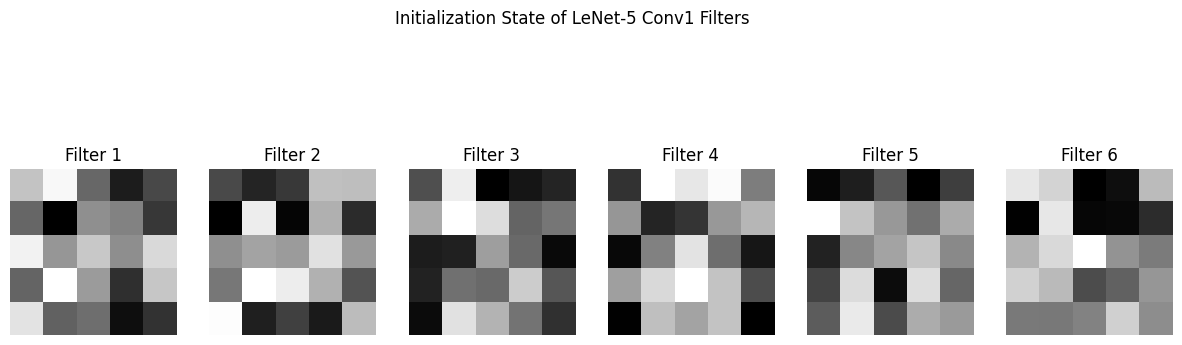

In [55]:
import matplotlib.pyplot as plt

# Instantiate the model
model = LeNet5(num_classes=10)

# Extract filters from the first convolutional layer
filters = model.conv1.weight.detach()

# Plotting the filters
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Standard convolution filters have depth (channels); we take the first slice
    # Since MNIST is grayscale, input_channels = 1
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('Initialization State of LeNet-5 Conv1 Filters')
plt.show()

## Loading and Visualizing MNIST Dataset

Loading the MNIST dataset using `torchvision` and displaying some sample images.

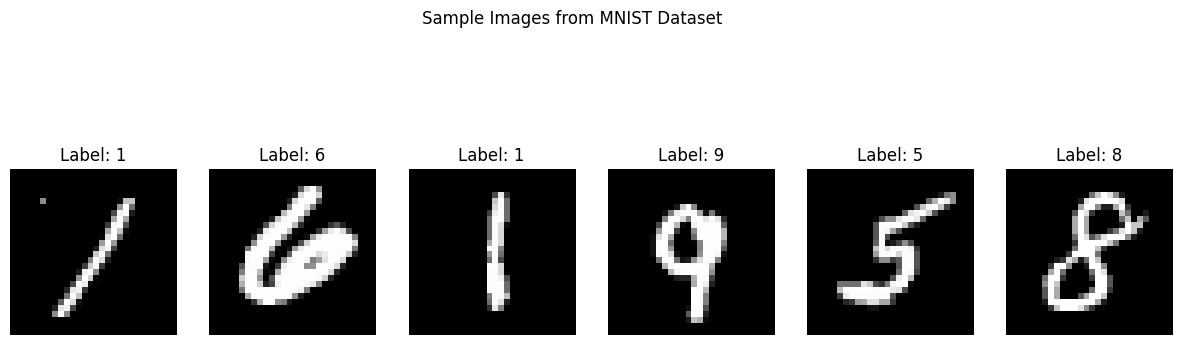

In [63]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transform to convert images to tensors
transform = transforms.Compose([transforms.ToTensor()])

# Download and load training data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)

# Get some random images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plot images
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Sample Images from MNIST Dataset')
plt.show()

## Visualizing Feature Maps (Layer 1 Activations)
Let's see what features the first convolutional layer (conv1) extracts from a sample image. We'll pass an image through the first layer and plot the resulting 6 feature maps.

Visualizing feature maps for digit: 5


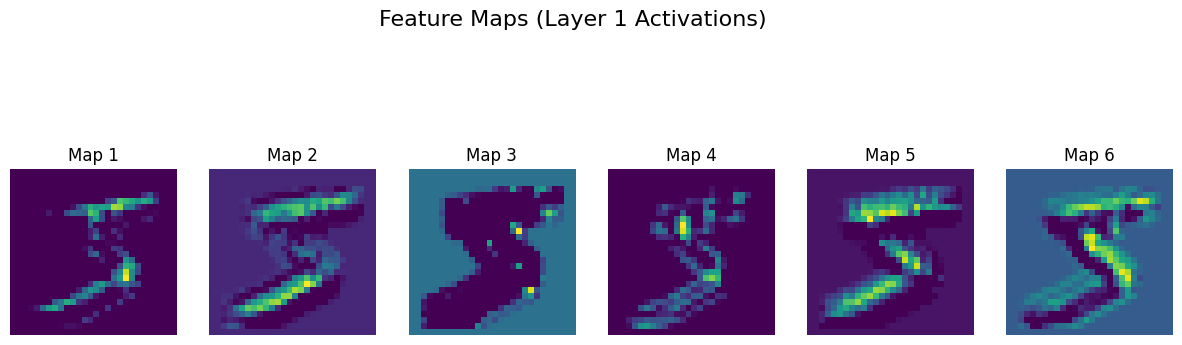

In [64]:
# Get a single sample image from the dataset
sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0) # Add batch dimension [1, 1, 28, 28]

# Passage through the first layer ONLY (Conv1 + ReLU)
model.eval()
with torch.no_grad():
    # Move sample to the same device as the model (if applicable)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    sample_image = sample_image.to(device)
    
    feature_maps = F.relu(model.conv1(sample_image))

# Move back to CPU for plotting
feature_maps = feature_maps.cpu().squeeze(0) # [6, 28, 28]

print(f"Visualizing feature maps for digit: {sample_label}")

# Plotting
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i in range(6):
    axes[i].imshow(feature_maps[i], cmap='viridis')
    axes[i].set_title(f'Map {i+1}')
    axes[i].axis('off')

plt.suptitle(f'Feature Maps (Layer 1 Activations)', fontsize=16)
plt.show()

## Training the Network

setting up the training loop wite CrossEntropyLoss and Adam optimizer. we´ll use a larger batch size for efficient training

In [48]:
import torch.optim as optim

# Device configuration (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Hyperparameters
learning_rate = 0.001
batch_size = 64
num_epochs = 5

# Update DataLoader with larger batch size for training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
print(f'Training on {device}...')
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}')

print('Training complete!')

Training on cpu...
Epoch [1/5] - Loss: 0.2733
Epoch [2/5] - Loss: 0.0706
Epoch [3/5] - Loss: 0.0486
Epoch [4/5] - Loss: 0.0403
Epoch [5/5] - Loss: 0.0315
Training complete!


## Evaluating the Model & Collecting Misclassified Samples

In [49]:
# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Collect misclassified samples
misclassified_images = []
misclassified_labels = []
predicted_labels     = []

model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

        # Collect misclassified
        mask = predicted != labels
        if mask.any():
            misclassified_images.append(images[mask].cpu())
            misclassified_labels.append(labels[mask].cpu())
            predicted_labels.append(predicted[mask].cpu())

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 98.33%


## Visualizing misclassified images
Let's see where the model gets confused by plotting some of the misclassified images from the test set

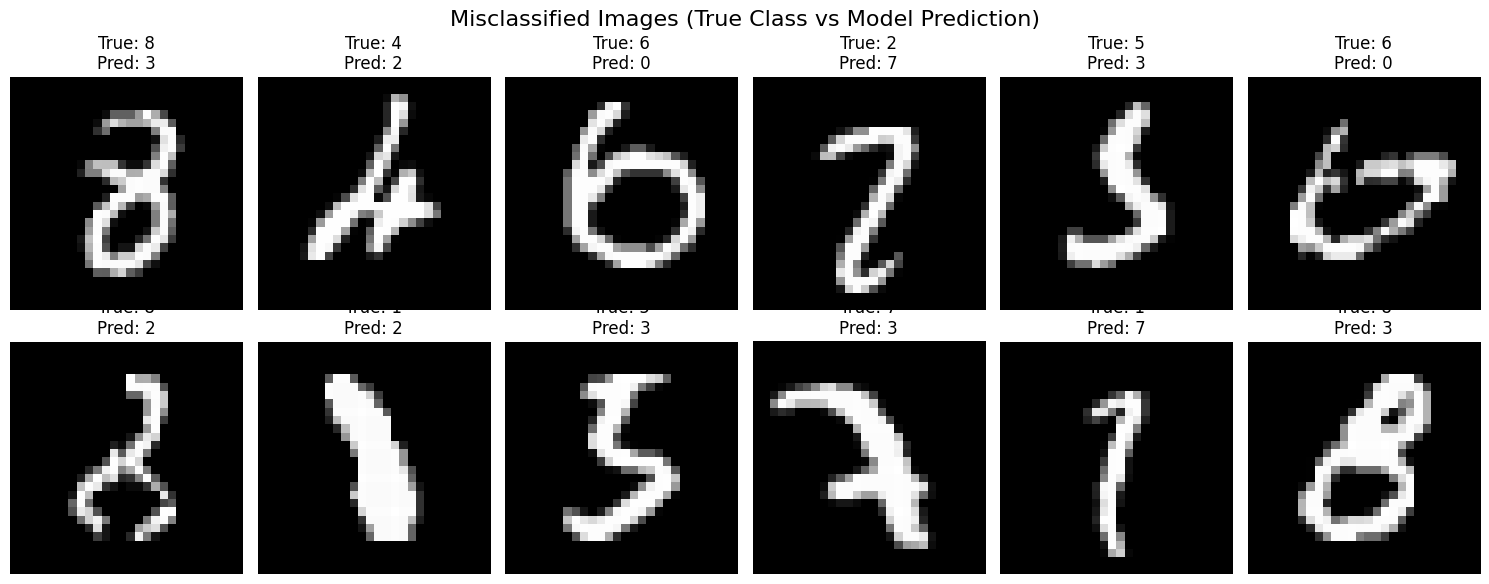

In [50]:
# Concatenate all collected misclassified samples
misclassified_images = torch.cat(misclassified_images)
misclassified_labels = torch.cat(misclassified_labels)
predicted_labels = torch.cat(predicted_labels)

# Display first 12 misclassified images
num_to_show = min(12, len(misclassified_images))
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(num_to_show):
    ax = axes[i // 6, i % 6]
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {misclassified_labels[i].item()}\nPred: {predicted_labels[i].item()}')
    ax.axis('off')

plt.suptitle('Misclassified Images (True Class vs Model Prediction)', fontsize=16)
plt.tight_layout()
plt.show()

## Evaluating the Performance

Now well load the dataset and calculate the overall accuracy of our trained model

In [51]:
# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# No gradient calculation needed during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10,000 test images: 98.33%


## Saving the Model
Best practice in PyTorch is to save the state_dict which contains only the learned parameters.

In [65]:
import os

# Create 'weights' directory if it doesn't exist
os.makedirs('weights', exist_ok=True)

# Set save path
PATH = './weights/lenet5_mnist.pth'

torch.save(model.state_dict(), PATH)
print(f"Model saved to {PATH}")

Model saved to ./weights/lenet5_mnist.pth


## Loading the Model for Later Use
Here's how to recreate the model and load the saved weights.

In [32]:
# 1. Create a new instance of the model
new_model = LeNet5(num_classes=10)

# 2. Load the state dictionary
new_model.load_state_dict(torch.load('./weights/lenet5_mnist.pth'))

# 3. Set to evaluation mode if you're using it for inference
new_model.eval()

print("New model instance created and weights loaded successfully!")

New model instance created and weights loaded successfully!
